# Relative GLV — 20 realizations, observables for visual judgement

Scale-invariant (relative) GLV: interactions act on the **mean firm** $m=M/N$, so the aggregate grows
exponentially with no finite-time blow-up. Integrated on the simplex (shares $w$) + log-scale ($\ln M$):

$$f_i = 1 - N w_i - N(\alpha w)_i,\qquad \dot w_i = w_i(f_i-\langle f\rangle) + \lambda\,(1/N - w_i),\qquad \tfrac{d\ln M}{dt}=\langle f\rangle = g_\mathrm{eff}.$$

Edit the **CONFIG** cell, then *Run All*. Six panels let you judge the MSB stylized facts by eye:

1. **$M(t)$** (log) — is the economy growing? exponential?
2. **Sample share trajectories** — persistent fluctuations vs freezing.
3. **Stationarity** — rolling growth-volatility vs $t$: flat = sustained, decaying = relaxation transient.
4. **Size$-$volatility** — does growth-rate volatility *decay* with firm size? ($\beta>0$, slope $+R^2$).
5. **Growth-rate distribution (the tent)** — fat-tailed? symmetric? vs Laplace / Gaussian.
6. **Summary table** — per-realization $g_\mathrm{eff}$, survival, $\sigma_g$, stationarity ratio, $\beta$, $R^2$, Bowley, kurtosis.

Default cell is the headline operating point $\sigma=1.90,\ \mu=2.35$ at $N=4000$.


In [1]:
import numpy as np
import networkx as nx
from scipy import sparse
from scipy.integrate import solve_ivp
from scipy.stats import kurtosis, laplace, norm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd

# ============================ CONFIG (edit me) ============================
MU       = 2.35        # mean competition (headline cell)
SIGMA    = 1.90        # disorder strength
LAM      = 1e-3        # immigration / share floor  lambda*(1/N - w)
N        = 4000        # number of firms
N_SEEDS  = 20          # realizations
TMAX     = 400.0       # integration horizon
N_EVAL   = 1600        # stored time points
RTOL, ATOL = 1e-4, 1e-7  # loose: we want trajectory STATISTICS, not exact paths
MAX_NFEV = 80000       # abort an explosive/stiff realization (flagged, not measured)
N_JOBS   = 6           # joblib workers
MID_WIN  = (240.0, 310.0)   # stationarity: earlier window
LATE_WIN = (320.0, 390.0)   # observables + later window
# graph / disorder (Roy power-law configuration model) -- INLINED below, not imported
ALPHA_PL, MEAN_DEGREE, GAMMA = 2.5, 100, 0.0
# =========================================================================
TGRID = np.linspace(0.0, TMAX, N_EVAL)
print(f'relative GLV | mu={MU} sigma={SIGMA} lam={LAM} N={N} seeds={N_SEEDS} TMAX={TMAX}')


relative GLV | mu=2.35 sigma=1.9 lam=0.001 N=4000 seeds=20 TMAX=400.0


## Model + measurement
Disorder/graph construction is **inlined** here (project convention) so you can tweak it directly: Roy
interactions on a power-law configuration-model graph, scaled to per-edge mean $\mu/C$, std $\sigma/\sqrt{C}$.
`measure(seed)` integrates one realization (RK45) and returns a compact record with everything the panels need.


In [2]:
class _Capped(Exception):
    """Raised once MAX_NFEV is exceeded -> abort a too-stiff (explosive) realization."""
    pass


def build_alpha(seed, S, mu, sigma):
    """Roy disorder on a power-law configuration-model graph. Per-edge mean mu/C, std sigma/sqrt(C)."""
    rng = np.random.default_rng(seed)
    C = min(MEAN_DEGREE, S - 1)
    kmin = C * (ALPHA_PL - 2) / (ALPHA_PL - 1)
    deg = np.maximum((kmin * (1 - rng.uniform(size=S)) ** (-1 / (ALPHA_PL - 1))).round().astype(int), 1)
    if deg.sum() % 2:
        deg[deg.argmin()] += 1
    G = nx.Graph(nx.configuration_model(deg.tolist(), seed=int(seed)))
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_scipy_sparse_array(G, format='csr', dtype=float); A.data[:] = 1.0
    C_eff = float(np.asarray(A.sum(1)).mean())
    Au = sparse.triu(A, k=1).tocoo(); ei, ej = Au.row, Au.col; nE = ei.size
    a = rng.normal(0, 1, nE); b = rng.normal(0, 1, nE)
    sym = (a + b) / np.sqrt(2); anti = (a - b) / np.sqrt(2)
    scale = sigma / np.sqrt(2 * C_eff)                       # -> per-edge std sigma/sqrt(C)
    w_ij = mu / C_eff + scale * (np.sqrt(1 + GAMMA) * sym + np.sqrt(1 - GAMMA) * anti)
    w_ji = mu / C_eff + scale * (np.sqrt(1 + GAMMA) * sym - np.sqrt(1 - GAMMA) * anti)
    rows = np.concatenate([ei, ej]); cols = np.concatenate([ej, ei])
    alpha = sparse.csr_array((np.concatenate([w_ij, w_ji]), (rows, cols)), shape=(S, S))
    return alpha, C_eff


def _incr(W, t, w0, w1, step=0.5):
    """Survivors in [w0,w1] and their Delta ln S increments on a regular grid (S_i = N w_i)."""
    surv = np.where(W[:, (t >= w0) & (t <= w1)].min(1) > 1e-6)[0]
    tg = np.arange(w0, w1 + 1e-9, step)
    if surv.size:
        lnS = np.array([np.interp(tg, t, np.log(np.maximum(N * W[i], 1e-12))) for i in surv])
        g = np.diff(lnS, axis=1)
    else:
        lnS = np.empty((0, tg.size)); g = np.empty((0, max(tg.size - 1, 0)))
    return surv, lnS, g


def measure(seed):
    alpha, _ = build_alpha(seed, N, MU, SIGMA)
    rng = np.random.default_rng(seed + 1); w0 = rng.uniform(0.5, 1.5, N); w0 /= w0.sum()
    nev = [0]
    def rhs(t, st):
        nev[0] += 1
        if nev[0] > MAX_NFEV:
            raise _Capped()
        w = np.clip(st[:N], 0.0, None); s = w.sum()
        if s > 0:
            w = w / s
        f = 1.0 - N * w - N * (alpha @ w); fb = float(w @ f)
        return np.concatenate([w * (f - fb) + LAM * (1.0 / N - w), [fb]])
    rec = dict(seed=int(seed), capped=False, success=False)
    try:
        r = solve_ivp(rhs, (0, TMAX), np.concatenate([w0, [0.0]]), method='RK45',
                      t_eval=TGRID, rtol=RTOL, atol=ATOL)
    except _Capped:
        rec['capped'] = True; return rec
    rec['success'] = bool(r.success)
    t = r.t; W = np.clip(r.y[:N], 0, None); W = W / W.sum(0, keepdims=True); lnM = r.y[N]
    rec['t'] = t; rec['lnM'] = lnM
    lh = t > 0.5 * t[-1]
    rec['g_eff'] = float(np.polyfit(t[lh], lnM[lh], 1)[0])      # aggregate growth rate (late half)
    # sample share trajectories: 15 biggest + 15 random firms (S_i = N w_i)
    rng2 = np.random.default_rng(seed + 7)
    samp = np.unique(np.concatenate([np.argsort(W[:, -1])[-15:], rng2.choice(N, 15, replace=False)]))
    rec['samp_S'] = (N * W[samp]).astype(np.float32)
    # rolling stationarity curve: std(Delta ln S) in consecutive windows across the run
    ct, gs = [], []
    for c in np.arange(80.0, TMAX - 30.0, 20.0):
        _, _, g = _incr(W, t, c - 15, c + 15)
        if g.size > 50:
            ct.append(c); gs.append(float(g.std()))
    rec['roll_t'] = np.array(ct); rec['roll_gstd'] = np.array(gs)
    # mid / late window scalars
    _, _, gm = _incr(W, t, *MID_WIN); rec['gstd_mid'] = float(gm.std()) if gm.size > 50 else 0.0
    sl, lnSl, gl = _incr(W, t, *LATE_WIN)
    rec['gstd_late'] = float(gl.std()) if gl.size > 50 else 0.0
    rec['surv_frac'] = float(sl.size / N)
    # the tent: pooled MSB-rescaled Delta ln S (sqrt(pi/2)*MAD, NOT std; std inflated by fat tails), subsampled
    flat = gl.ravel(); flat = flat[np.isfinite(flat)]
    if flat.size > 200:
        scale = np.sqrt(np.pi / 2) * np.abs(flat - flat.mean()).mean(); z = (flat - flat.mean()) / (scale if scale > 0 else 1.0)
        rec['growth_z'] = (rng2.choice(z, 8000, replace=False) if z.size > 8000 else z).astype(np.float32)
        q1, q2, q3 = np.percentile(flat, [25, 50, 75])
        rec['bowley'] = float((q3 + q1 - 2 * q2) / (q3 - q1)) if q3 > q1 else np.nan
        rec['exkurt'] = float(kurtosis(flat))
    else:
        rec['growth_z'] = np.array([], np.float32); rec['bowley'] = np.nan; rec['exkurt'] = np.nan
    # size-volatility (survivors, late window): Sbar vs vol, decline-branch beta + R^2
    rec['beta'] = np.nan; rec['r2'] = np.nan
    if sl.size >= 50:
        Sbar = np.exp(lnSl).mean(1)
        vol = np.sqrt(np.pi / 2) * np.abs(gl - gl.mean(1, keepdims=True)).mean(1)
        live = (vol > 0) & np.isfinite(vol) & (Sbar > 0); Sbar, vol = Sbar[live], vol[live]
        rec['sv_S'] = Sbar.astype(np.float32); rec['sv_vol'] = vol.astype(np.float32)
        o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), 20)
        bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
        m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
        rec['bin_S'] = bx; rec['bin_vol'] = by
        if bx.size > 5:
            pk = int(np.argmax(by))
            if by.size - pk >= 5:
                c = np.polyfit(np.log10(bx[pk:]), np.log10(by[pk:]), 1)
                yh = np.polyval(c, np.log10(bx[pk:]))
                ss = np.sum((np.log10(by[pk:]) - np.log10(by[pk:]).mean()) ** 2)
                rec['beta'] = float(-c[0]); rec['pk'] = pk
                rec['r2'] = float(1 - np.sum((np.log10(by[pk:]) - yh) ** 2) / ss) if ss > 0 else np.nan
    return rec


## Run the 20 realizations
~1 min at $N=4000$ on 6 cores. Each realization returns a compact record (no full $W$ kept), so the panels
below re-plot instantly without re-simulating.


In [3]:
%time recs = Parallel(n_jobs=N_JOBS, backend='loky', verbose=5)(delayed(measure)(s) for s in range(N_SEEDS))
ok = [r for r in recs if not r['capped']]
print(f'{len(ok)}/{N_SEEDS} integrated; {N_SEEDS - len(ok)} capped (explosive/stiff)')


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  1.0min
[Parallel(n_jobs=6)]: Done  14 out of  20 | elapsed:  1.7min remaining:   44.4s


CPU times: user 365 ms, sys: 210 ms, total: 575 ms
Wall time: 3min 3s
18/20 integrated; 2 capped (explosive/stiff)


[Parallel(n_jobs=6)]: Done  20 out of  20 | elapsed:  3.1min finished


## Panel 6 — summary table (run first; the numbers frame the plots)

In [4]:
def _g(r, k): return r.get(k, np.nan)
rows = [dict(seed=r['seed'], capped=r['capped'], g_eff=_g(r, 'g_eff'), surv=_g(r, 'surv_frac'),
             gstd_late=_g(r, 'gstd_late'),
             stat=(_g(r, 'gstd_late') / r['gstd_mid']) if r.get('gstd_mid', 0) > 1e-9 else np.nan,
             beta=_g(r, 'beta'), r2=_g(r, 'r2'), bowley=_g(r, 'bowley'), exkurt=_g(r, 'exkurt'))
        for r in recs]
df = pd.DataFrame(rows).set_index('seed')
med = df.median(numeric_only=True)
print('median across realizations  (stat~1 = sustained; beta>0 = vol decays with size; bowley~0 = symmetric):')
print(med.round(3).to_string())
print('\nclean-fit median (R^2 > 0.8 only):')
print(df[df['r2'] > 0.8][['beta', 'r2']].median().round(3).to_string())
df.round(3)


median across realizations  (stat~1 = sustained; beta>0 = vol decays with size; bowley~0 = symmetric):
capped        0.000
g_eff         0.225
surv          0.198
gstd_late     0.296
stat          1.131
beta          0.299
r2            0.846
bowley        0.018
exkurt       12.222

clean-fit median (R^2 > 0.8 only):
beta    0.388
r2      0.903


,capped,g_eff,surv,gstd_late,stat,beta,r2,bowley,exkurt
seed,,,,,,,,,
0,False,0.091,0.240,0.268,1.134,0.330,0.878,0.031,10.219
1,False,-0.185,0.278,0.168,1.129,0.411,0.944,0.001,15.821
2,False,-0.069,0.164,0.344,0.992,0.172,0.756,0.044,16.530
3,False,-0.140,0.205,0.354,0.902,0.229,0.355,0.043,12.675
4,False,0.832,0.050,0.547,1.156,0.231,0.580,-0.005,7.940
5,False,0.455,0.114,0.379,1.028,0.178,0.660,0.020,7.924
6,False,0.631,0.076,0.640,1.301,0.112,0.484,0.034,12.628
7,False,0.595,0.279,0.144,1.272,0.567,0.949,0.007,12.628
8,False,0.114,0.227,0.202,0.889,0.367,0.890,-0.001,18.200


## Panel 1 — aggregate $M(t)$ (is the economy growing? exponential?)

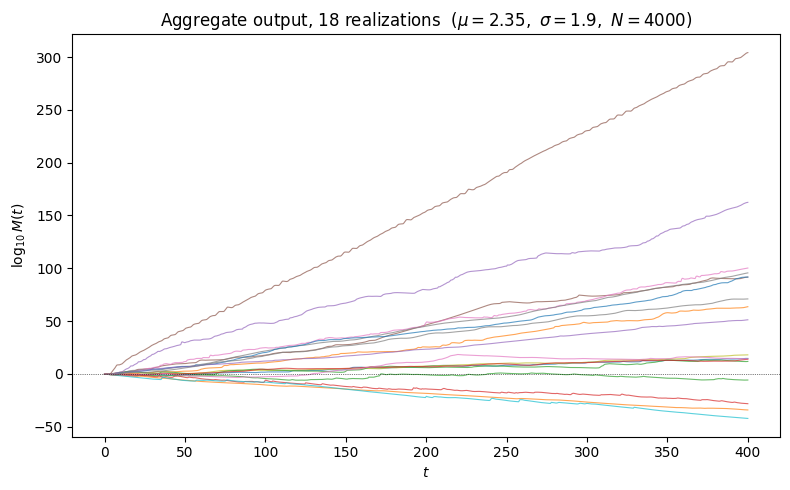

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for r in ok:
    ax.plot(r['t'], r['lnM'] / np.log(10), lw=0.8, alpha=0.7)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set(xlabel='$t$', ylabel=r'$\log_{10} M(t)$',
       title=fr'Aggregate output, {len(ok)} realizations  ($\mu={MU},\ \sigma={SIGMA},\ N={N}$)')
plt.tight_layout(); plt.show()


## Panel 2 — sample relative sizes $S_i=N w_i$ (persistent fluctuations vs freezing)
Two realizations; each line is one firm (15 largest + 15 random). Wiggling late = sustained chaos; flat lines = frozen.


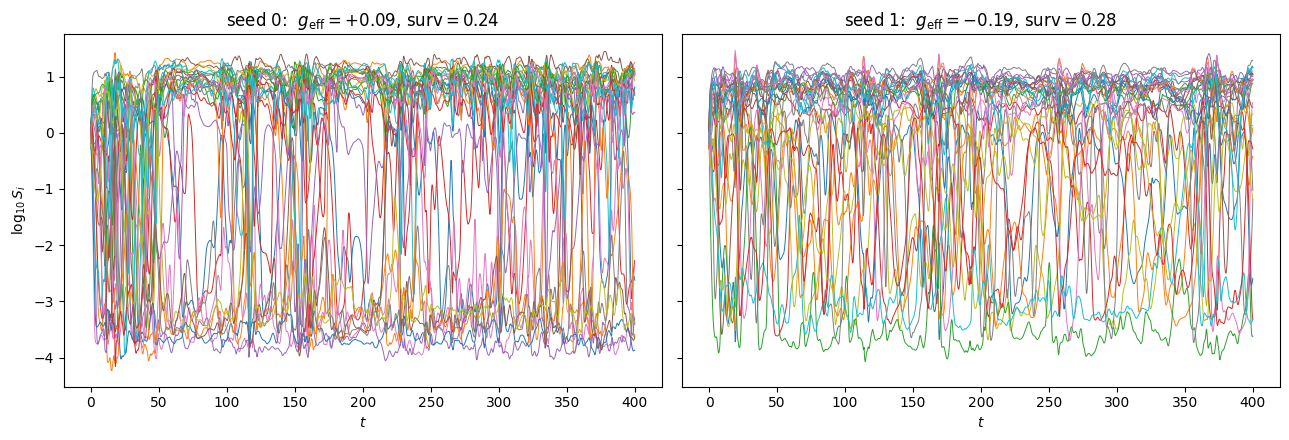

In [6]:
show = ok[:2] if len(ok) >= 2 else ok
fig, axs = plt.subplots(1, len(show), figsize=(6.5 * len(show), 4.5), sharey=True, squeeze=False)
for ax, r in zip(axs[0], show):
    for row in r['samp_S']:
        ax.plot(r['t'], np.log10(np.maximum(row, 1e-8)), lw=0.7)
    ax.set(xlabel='$t$', title=fr"seed {r['seed']}:  $g_\mathrm{{eff}}={r['g_eff']:+.2f}$, surv$={r['surv_frac']:.2f}$")
axs[0][0].set_ylabel(r'$\log_{10} S_i$')
plt.tight_layout(); plt.show()


## Panel 3 — stationarity (flat = sustained fluctuations, decaying = relaxation transient)
Each line is one realization's $\mathrm{std}(\Delta\ln S)$ in a sliding window. The shaded bands are the mid/late
windows used for the `stat` ratio in the table. **This is the key honesty check** — the project has been burned by
slow relaxation faking stationarity.


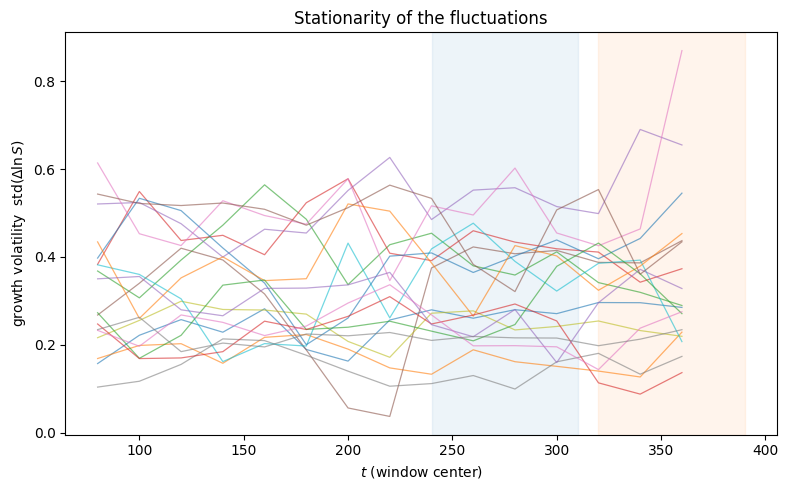

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for r in ok:
    if len(r.get('roll_t', [])):
        ax.plot(r['roll_t'], r['roll_gstd'], lw=0.9, alpha=0.6)
ax.axvspan(*MID_WIN, color='C0', alpha=0.08); ax.axvspan(*LATE_WIN, color='C1', alpha=0.08)
ax.set(xlabel='$t$ (window center)', ylabel=r'growth volatility  $\mathrm{std}(\Delta\ln S)$',
       title='Stationarity of the fluctuations')
plt.tight_layout(); plt.show()


## Panel 4 — size$-$volatility (does volatility decay with size? $\beta>0$)
Grey: survivors pooled. Coloured: per-realization binned medians. Guide lines: empirical $\beta=0.2$ and the
median fitted $\beta$. **Only the decline branch (large $S$) is fit** — small firms sit on the immigration-floor
plateau, so a full-range fit is shape-spurious. Watch $R^2$ in the table: low-$R^2$ realizations are not a clean power law.


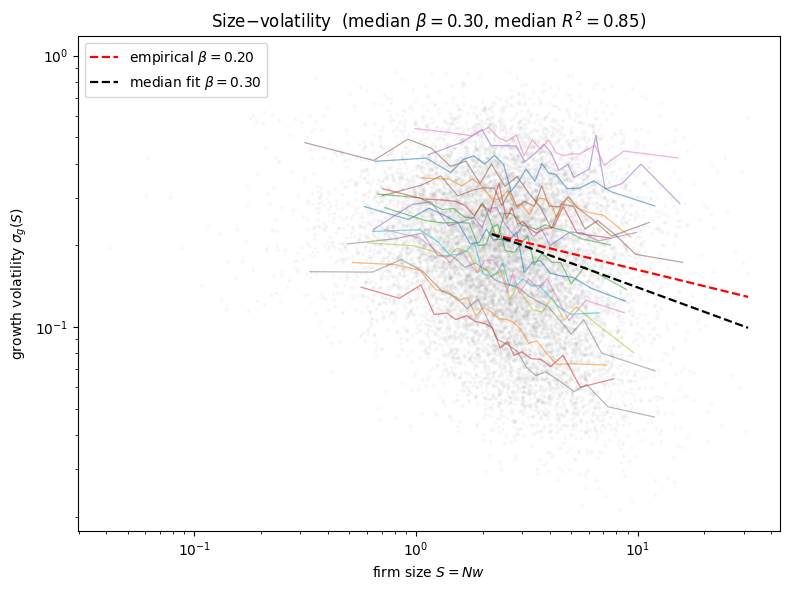

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for r in ok:
    if 'sv_S' in r:
        ax.scatter(r['sv_S'], r['sv_vol'], s=3, alpha=0.04, color='grey')
for r in ok:
    if 'bin_S' in r and np.isfinite(_g(r, 'beta')):
        ax.plot(r['bin_S'], r['bin_vol'], lw=0.9, alpha=0.55)
bmed = np.nanmedian([_g(r, 'beta') for r in ok]); rmed = np.nanmedian([_g(r, 'r2') for r in ok])
allS = np.concatenate([r['sv_S'] for r in ok if 'sv_S' in r])
xx = np.array([np.percentile(allS, 40), allS.max()])
y0 = np.nanmedian([np.median(r['sv_vol']) for r in ok if 'sv_vol' in r])
for b, c, lab in [(0.20, 'r', r'empirical $\beta=0.20$'), (bmed, 'k', fr'median fit $\beta={bmed:.2f}$')]:
    ax.plot(xx, y0 * (xx / xx[0]) ** (-b), c + '--', lw=1.6, label=lab)
ax.set(xscale='log', yscale='log', xlabel=r'firm size $S=N w$', ylabel=r'growth volatility $\sigma_g(S)$',
       title=fr'Size$-$volatility  (median $\beta={bmed:.2f}$, median $R^2={rmed:.2f}$)')
ax.legend()
plt.tight_layout(); plt.show()


## Panel 5 — growth-rate distribution (the tent: fat-tailed? symmetric?)
Pooled MSB-rescaled $\Delta\ln S$ (subtract mean, divide by $\sqrt{\pi/2}\,$MAD, not std) over all realizations. **Laplace** (red dashed) and **Gaussian** (black dotted)
references. Log-y exposes the tails: above Gaussian = fat; matching/above Laplace = MSB-like. Symmetry by eye +
median Bowley in the titles.


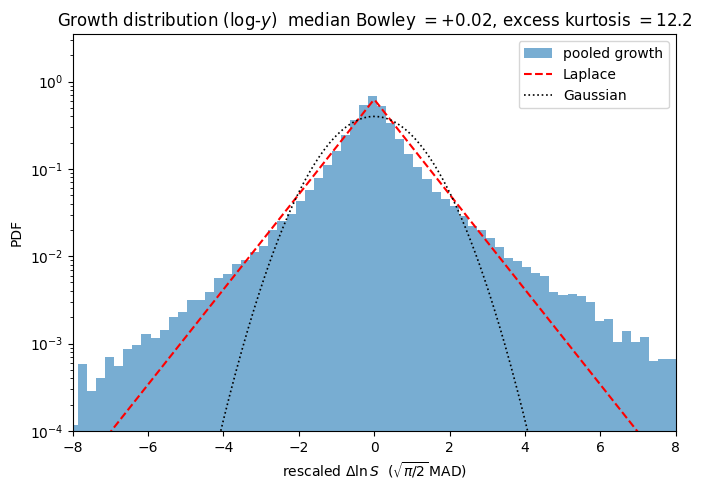

In [13]:
allz = np.concatenate([r['growth_z'] for r in ok if r.get('growth_z', np.array([])).size])
allz = (allz - allz.mean()) / (np.sqrt(np.pi / 2) * np.abs(allz - allz.mean()).mean())  # MSB MAD-rescale; idempotent -> also corrects stale std-scaled growth_z without a re-sim
xx = np.linspace(-8, 8, 400)
bw = np.nanmedian([_g(r, 'bowley') for r in ok]); ek = np.nanmedian([_g(r, 'exkurt') for r in ok])
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(allz, bins=160, density=True, color='C0', alpha=0.6, label='pooled growth')
ax.plot(xx, laplace.pdf(xx, scale=np.sqrt(2 / np.pi)), 'r--', lw=1.5, label='Laplace')
ax.plot(xx, norm.pdf(xx), 'k:', lw=1.2, label='Gaussian')
ax.set_yscale('log'); ax.set_ylim(1e-4, None)
ax.set(xlabel=r'rescaled $\Delta\ln S$  $(\sqrt{\pi/2}\,\mathrm{MAD})$', ylabel='PDF', xlim=(-8, 8)); ax.legend()
ax.set_title(fr'Growth distribution (log-$y$)  median Bowley $={bw:+.2f}$, excess kurtosis $={ek:.1f}$')
plt.tight_layout(); plt.show()